# Exercise 8

This exercise is based on Chapter 5 (Choropleth Mapping) of the Geographic Data Science book.

The material can be found in: `GSP538/gds_book/notebooks/05_choropleth.ipynb`

#### Notes on Textbook

- You might notice that this is a different perspective on a topic (choropleth mapping) than you have seen multiple times by now. The first map does not come until 2/3 of the way through the chapter. Much of the content links back to the statistics refresher you did earlier in the semester.
- This is the same "interval notation" seen earlier in the semester.

#### Answer the following written questions

There is a blank Markdown cell after each question for your answer (double click in the blank cell to type your answer). Be sure to run your Markdown cells to format your answers.

1. What is the difference between classed and unclassed maps for quantitative data?

**Classed maps** group attribute values into a smaller number of discrete classes (typically ≤12), where each class is assigned a unique color or symbol. All observations within a class receive the same visual encoding. **Unclassed maps** assign a distinct color to each unique attribute value — essentially a continuous color gradient. Although modern technology makes unclassed maps feasible, classed maps remain preferred because they reduce cognitive load, draw on statistical theory for effective representation, and better encode the spatial distribution of attribute values.

2. Provide some intuition on how choropleth maps are similar to histograms.

Choropleth maps and histograms solve the same fundamental problem: partitioning continuous data into mutually exclusive and exhaustive groups. In a histogram, the x-axis is divided into bins and the height of each bar represents the count of observations in that bin. In a choropleth map, the same bin boundaries become classification break points, and each polygon is colored based on which bin its value falls into. The histogram shows the statistical distribution (how many observations per class), while the choropleth shows the spatial distribution (where those classes are located geographically). Both are complementary views of the same classification.

3. The books says, the Freedman-Diaconis (FD) rule is "a special case of a more general classifier known as 'equal intervals'." You have seen equal intervals classification in previous classes. However, this might be the first time you have seen the FD rule. Why does the user need to pass in a value for k when using the classic equal intervals algorithm but not when using the FD rule? How is this useful and not useful for the user?

The classic equal intervals algorithm requires the user to specify $k$ because it simply divides the range into $k$ equal-width bins — it has no way to determine the "right" number of classes on its own. The Freedman-Diaconis (FD) rule computes $k$ automatically using the formula $w = 2 \cdot IQR \cdot n^{-1/3}$ for bin width, then $k = (max - min) / w$. Since $w$ is derived from the inter-quartile range and sample size, $k$ is data-driven and requires no user input.

This is **useful** because the FD rule removes the subjective choice of $k$ and adapts to the data's spread and sample size. It is **not useful** when the analyst has domain knowledge that calls for a specific number of classes (e.g., "I want exactly 5 groups for policy purposes"), or when the FD-determined $k$ produces too many or too few bins for the intended map audience.

4. Explain the mean-standard deviation classifier and the conditions under which it is useful.

The mean-standard deviation classifier uses the sample mean ($\bar{x}$) and standard deviation ($s$) to define class boundaries. For $k=5$, the break points are: $\bar{x} - 2s$, $\bar{x} - s$, $\bar{x}$, $\bar{x} + s$, and $\bar{x} + 2s$. This creates classes centered on the mean, with each class spanning one standard deviation.

It is most useful when the data is **normally distributed** (or at least roughly symmetric), because the class boundaries align naturally with the bell curve and each class captures a predictable proportion of the data (e.g., ~68% within ±1s, ~95% within ±2s). For skewed data, it performs poorly — most observations crowd into one or two classes, and the boundary at $\bar{x} - 2s$ may produce inadmissible negative values for data that is inherently non-negative.

5. Describe the range of each of the six classes in the box-plot classification. (Hint: the textbook description could be clearer; sketching a picture of a boxplot may help identify the six areas and their ranges.)

The box-plot classifier uses the quartiles and IQR to define exactly **six** classes (where $h$ is the hinge, typically 1.5):

1. **Lower outliers:** $[min,\ Q_1 - h \cdot IQR)$ — values below the lower whisker
2. **Lower whisker to Q1:** $[Q_1 - h \cdot IQR,\ Q_1)$ — low but not outlier values
3. **Q1 to median:** $[Q_1,\ Q_2)$ — lower-middle values
4. **Median to Q3:** $[Q_2,\ Q_3)$ — upper-middle values
5. **Q3 to upper whisker:** $[Q_3,\ Q_3 + h \cdot IQR)$ — high but not outlier values
6. **Upper outliers:** $[Q_3 + h \cdot IQR,\ max]$ — values above the upper whisker

Note: if no observations fall beyond the whiskers, the outlier classes will be empty.

6. The textbook notes that an optimal solution is not guaranteed for Jenks-Caspall and Max-p because these are based on heuristic algorithms. The book does not define the term heuristic. Read a few webpages that define this term and give a definition in your own words. Link your answer back to choropleth mapping concepts and why the quantile approach (for example) does not require a heuristic algorithm.

A **heuristic algorithm** is a problem-solving approach that finds a good (but not necessarily optimal) solution through iterative improvement. It starts with an initial solution, makes incremental adjustments that improve the objective function, and stops when no further improvement can be found. The result is a local optimum, which may or may not be the global optimum.

In the context of choropleth classification, **Jenks-Caspall** and **Max-P** are heuristic — they start with initial class boundaries (e.g., from quantiles), then iteratively swap observations between adjacent classes to reduce within-class variation. They terminate when no swap improves the fit, but this does not guarantee the best possible classification. In contrast, **Fisher-Jenks** uses dynamic programming to exhaustively evaluate all possible partitions, guaranteeing the optimal solution.

**Quantiles** do not require a heuristic because the solution is deterministic: simply sort the data and place break points at the $n/k$ positions. There is no optimization problem to solve — the class boundaries are fixed by the definition of percentiles.

7. Go back to the yellow-green plot from the book with Mexican states on the x-axis and classification schemes on the y-axis. a) Overall, does this say that the eight classification schemes generally result in similar classifications of the Mexican states or generally different classifications? Explain your answer. b) Most adjacent pairs of states (on the x-axis) tend to be grouped together in all or most of the classification schemes. Which pair of states end up together in only two out of the eight classification schemes? What does this say about these two states relative each other?

**(a)** Overall, the eight classification schemes **generally result in similar classifications** for most states. The heatmap shows that most adjacent pairs of states on the x-axis (sorted by PCGDP1940) share the same color across nearly all schemes, meaning they are grouped into the same class regardless of method. However, the schemes differ most in where they place the boundaries, particularly for states near break points.

**(b)** The pair that ends up together in only two of the eight schemes is **Baja California Sur and Sonora** (the two states at the boundary between class 1 and class 2). Most classifiers place them in different classes because they straddle a natural break point in the data. This indicates that their PCGDP1940 values are very close to each other but sit right at a transition point, so most classification methods split them apart — only Equal Interval and Fisher-Jenks (which produce nearly identical boundaries for this data) keep them together.

8. Describe the different color pallets that should be used for sequential, diverging and qualitative data.

- **Sequential palettes** use a gradient from light to dark (or one hue to another) to represent ordered, continuous data where the emphasis is on magnitude from low to high. Examples: YlGn (yellow to green), Blues (light to dark blue). Best for data like income, population, or temperature.

- **Diverging palettes** use two contrasting hues that diverge from a neutral midpoint color. Light/neutral colors represent the center of the distribution, while dark colors at both ends emphasize the extremes. Best for data with a meaningful midpoint, such as change (positive/negative), deviation from the mean, or election margins. Examples: RdYlGn (red–yellow–green), RdBu (red–blue).

- **Qualitative palettes** use distinct, unrelated colors with no implied order or gradient. Each color represents a different category with equal visual weight. Best for nominal/categorical data such as land use types, regions, or political parties. These palettes must not suggest a ranking among categories.

#### The following questions require you to run Python code.

The cell below imports the GeoPandas package and the standard extra stuff to make things run smoother. Run this cell. 

In [3]:
import warnings
warnings.filterwarnings("ignore")

import geopandas as gpd

You will be working with precinct level 2020 presidential election data for Arizona.

   > The Upshot scraped and standardized precinct-level election results from around the country, and joined this tabular data to precinct GIS data to create a nationwide election map.
   
   https://www.kaggle.com/datasets/paultimothymooney/presidential-precinct-map-2020-election-results

9. Setup.
    - Read in `az_precincts_2020.geojson` from the `exercises/data` directory
    - Print the `info` method for the dataset
    - Create a basic map of the precincts (no need to fill the polygons with data)
    - Give a brief interpretation of the data based on the `info` and map outputs.

In [4]:
# Read in the data
gdf = gpd.read_file("data/az_precincts_2020.geojson")

# Print info
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   GEOID           1441 non-null   str     
 1   votes_dem       1441 non-null   float64 
 2   votes_rep       1441 non-null   float64 
 3   votes_total     1441 non-null   float64 
 4   votes_per_sqkm  1441 non-null   float64 
 5   cnty_id         1441 non-null   str     
 6   cnty_name       1441 non-null   str     
 7   geometry        1441 non-null   geometry
dtypes: float64(4), geometry(1), str(3)
memory usage: 90.2 KB


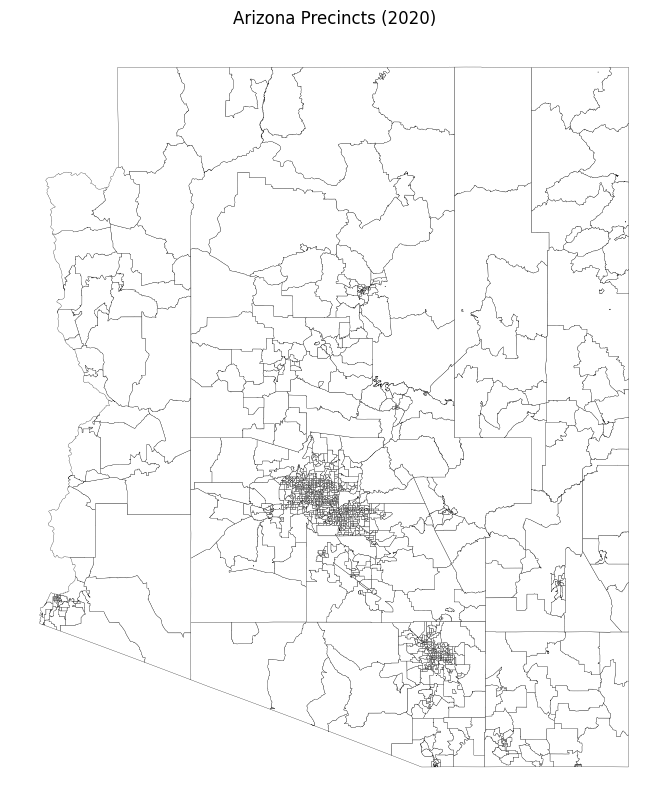

In [5]:
# Basic map of the precincts
ax = gdf.plot(figsize=(10, 10), edgecolor="black", linewidth=0.2, color="white")
ax.set_title("Arizona Precincts (2020)")
ax.set_axis_off()

The dataset contains 1,441 precincts across Arizona with 8 columns: a precinct identifier (GEOID), Democratic and Republican vote counts, total votes, voting density (votes per sq km), county identifier and name, and polygon geometry. There are no missing values in any column. The map shows the familiar shape of Arizona divided into precincts—urban areas like Maricopa County (Phoenix metro) have many small, densely packed precincts, while rural areas in northern and western Arizona have far fewer, much larger precincts. This reflects the large population concentration in the Phoenix and Tucson metropolitan areas.

10. Analyze the the statewide vote by precinct. 
    - Add a new column to the GeoDataFrame that contains the percent of the vote that went to the Republican. Multiply by 100 so the data looks like 24.3 (not 0.243).
    - Compute the mean, median, mode, skewness and kurtosis of the new column. 
    - Using these statistics, briefly describe the relationship of this column to the normal distribution. (Hint: just looking at a mean says nothing about the normal distribution. This response links back to stuff you learned earlier in the course, although skewness and kurtosis is new.)

In [6]:
from scipy import stats

# Add percent Republican column
gdf["pct_rep"] = (gdf["votes_rep"] / gdf["votes_total"]) * 100

# Compute statistics
print(f"Mean:     {gdf['pct_rep'].mean():.2f}")
print(f"Median:   {gdf['pct_rep'].median():.2f}")
print(f"Mode:     {gdf['pct_rep'].mode().values[0]:.2f}")
print(f"Skewness: {gdf['pct_rep'].skew():.4f}")
print(f"Kurtosis: {gdf['pct_rep'].kurtosis():.4f}")

Mean:     47.85
Median:   49.48
Mode:     50.00
Skewness: -0.1078
Kurtosis: -0.5868


The distribution of percent Republican vote by precinct departs from normality in several ways. The mean (47.85) and median (49.48) are close but not equal — the median is slightly higher than the mean, which is consistent with the negative skewness (−0.1078). This negative skewness indicates a left-skewed distribution with a longer tail of precincts that have very low Republican vote shares. The excess kurtosis (−0.5868) is negative (platykurtic), meaning the distribution has lighter tails and a flatter peak than a normal distribution. Together, these statistics show the data is approximately but not perfectly normal: a normal distribution would have skewness of 0 and excess kurtosis of 0. The left skew and platykurtic shape suggest more spread in the lower values and fewer extreme outliers than a true bell curve.

11. Comparing histograms.
    - Plot a histogram of the new column using Seaborn and all the default settings. 
    - Plot another using the histogram method of a GeoPandas GeoDataFrame (note: this is identical to the Pandas DataFrame method) using all the default settings.
    - Plot a third where you chose the bin size that you believe provides the most information about the distribution (plot using either Seaborn or Pandas; it must be a different number of bins from the previous two histograms).
    - Discuss the default settings of each (you will need to read their documentation) and why you chose the bin size you did.

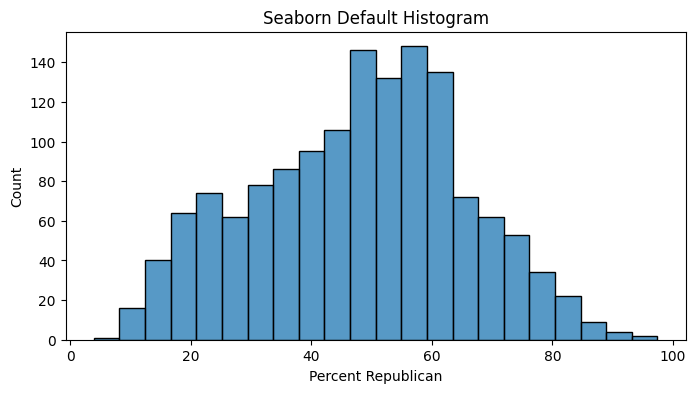

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn histogram with default settings
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(gdf["pct_rep"], ax=ax)
ax.set_title("Seaborn Default Histogram")
ax.set_xlabel("Percent Republican")
plt.show()

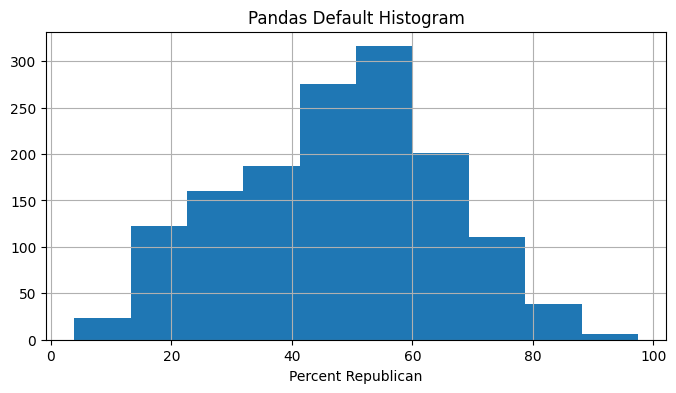

In [8]:
# Pandas/GeoPandas histogram with default settings
fig, ax = plt.subplots(figsize=(8, 4))
gdf["pct_rep"].hist(ax=ax)
ax.set_title("Pandas Default Histogram")
ax.set_xlabel("Percent Republican")
plt.show()

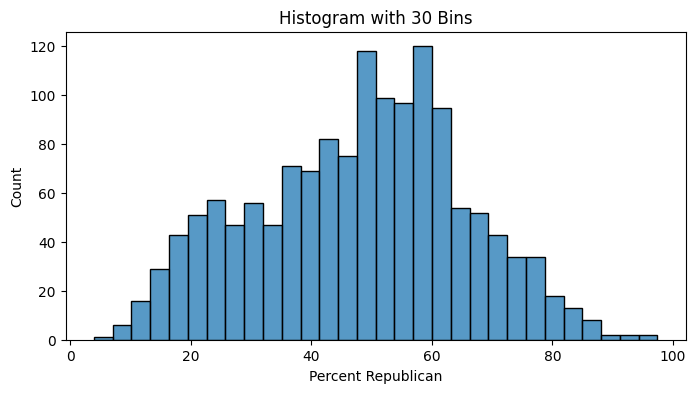

In [9]:
# Custom bin size histogram
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(gdf["pct_rep"], bins=30, ax=ax)
ax.set_title("Histogram with 30 Bins")
ax.set_xlabel("Percent Republican")
plt.show()

**Seaborn default:** Seaborn's `histplot` uses an automatic bin-width algorithm (Freedman-Diaconis or Sturges, whichever produces fewer bins) to determine the number of bins. This typically yields a moderate number of bins that balances detail and smoothness.

**Pandas default:** The Pandas `.hist()` method defaults to 10 bins regardless of the data. This is a fixed, simple rule that often produces a coarse view of the distribution.

**Custom choice (30 bins):** I chose 30 bins because 10 bins (Pandas default) is too coarse and hides important structure in the distribution — for example, it obscures whether there is bimodality or clustering near certain percentages. The Seaborn automatic method provides a reasonable number of bins, but 30 bins offers finer resolution that reveals more about the shape of the distribution (e.g., the left tail, the peak, and any secondary modes) without being so many bins that the histogram becomes noisy.

12. Create a new GeoDataFrame containing only the Santa Cruz County precincts. Santa Cruz County is located in the southeast corner of the state. 
    - Report the total number of votes in the county.
    - Run `describe` on the percent Republican votes column for the county.
    - Create a basic map of the county precincts (just the precincts, do not fill the polygons with data). Be sure lines between the precincts are clearly visible in the map. 
    - Based on visual inspection of these outputs, briefly discuss Santa Cruz County and its voting (note: don't just say, "the mean is ____ and the standard deviation is ____"; review it all and give a narrative based on the information here.)

In [10]:
# Create GeoDataFrame for Santa Cruz County
sc = gdf[gdf["cnty_name"] == "Santa Cruz"].copy()

# Total number of votes in the county
print(f"Total votes in Santa Cruz County: {sc['votes_total'].sum():,.0f}")
print()

# Describe the percent Republican column
print(sc["pct_rep"].describe())

Total votes in Santa Cruz County: 19,556

count    24.000000
mean     31.653579
std      12.031667
min      18.131868
25%      23.591077
50%      29.079011
75%      37.181966
max      63.176895
Name: pct_rep, dtype: float64


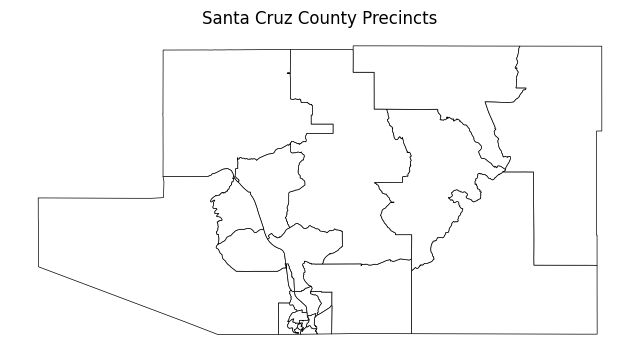

In [11]:
# Basic map of Santa Cruz County precincts
ax = sc.plot(figsize=(8, 8), edgecolor="black", linewidth=0.5, color="white")
ax.set_title("Santa Cruz County Precincts")
ax.set_axis_off()

Santa Cruz County is a small county in southeastern Arizona along the Mexican border with just 24 precincts and about 19,556 total votes — one of the smaller counties in the state. The county is strongly Democratic-leaning: the average precinct Republican vote share is about 31.7% with a median around 29.1%, both well below 50%. The maximum Republican vote in any precinct is about 63.2%, meaning even the most Republican precinct barely crosses the majority threshold. The standard deviation of ~12% and the gap between the 25th percentile (~23.6%) and 75th percentile (~37.2%) indicate moderate spread, with most precincts clustered in the 20–40% range. The map shows a mix of a few small, densely subdivided precincts near Nogales (the county seat, in the south) and larger rural precincts covering the rest of the county. Overall, this is one of Arizona's most solidly Democratic counties, consistent with its largely Hispanic, border-community population.

13. Create four individual choropleth maps of percent Republican votes for Santa Cruz County: equal interval, quantile, Fisher-Jenks and mean-standard deviation. Map formatting should include:
    - 5 classes
    - Show the legend
    - Use red color pallet (you are mapping Republican votes)
    - Ensure precinct lines are visible, but not exaggerated
    - Remove the axis with the mapping coordinates
    - Legend values should display one decimal place (e.g., 24.7)
    - Add `'loc':'upper left'` to `legend_kwds` to change the legend location; and `'fontsize':9` to change the legend text size

    Discuss your reaction to the different visual representations, recognizing that it is the same underlying data and same number of classes in all cases.

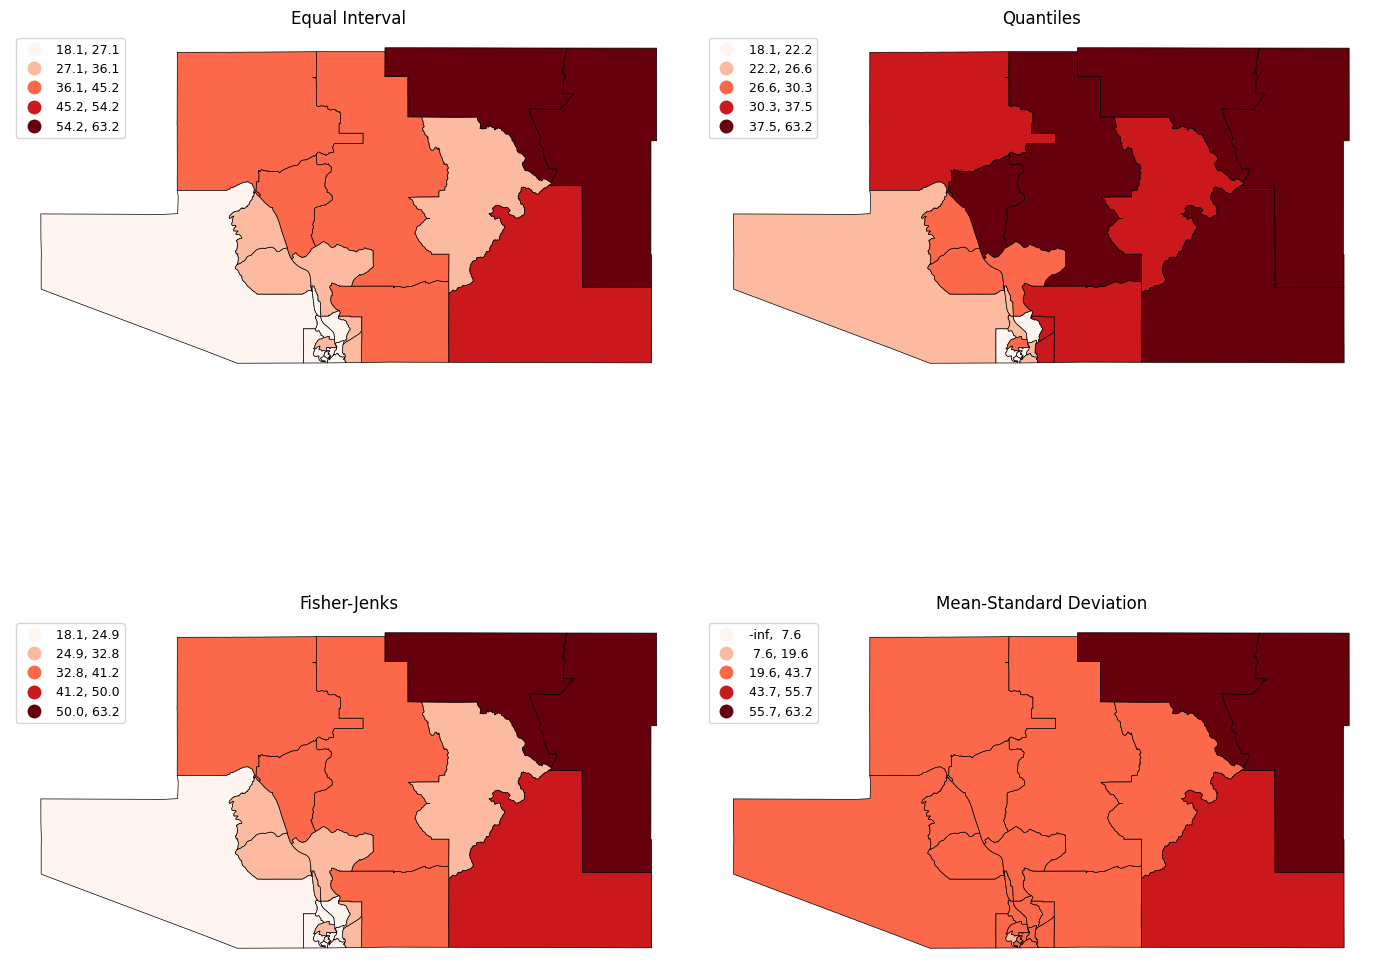

In [12]:
import mapclassify

schemes = ["EqualInterval", "Quantiles", "FisherJenks", "StdMean"]
titles = ["Equal Interval", "Quantiles", "Fisher-Jenks", "Mean-Standard Deviation"]

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for ax, scheme, title in zip(axes.flatten(), schemes, titles):
    if scheme == "StdMean":
        sc.plot(
            column="pct_rep",
            scheme=scheme,
            cmap="Reds",
            legend=True,
            edgecolor="black",
            linewidth=0.5,
            legend_kwds={"loc": "upper left", "fontsize": 9, "fmt": "{:.1f}"},
            ax=ax,
        )
    else:
        sc.plot(
            column="pct_rep",
            scheme=scheme,
            k=5,
            cmap="Reds",
            legend=True,
            edgecolor="black",
            linewidth=0.5,
            legend_kwds={"loc": "upper left", "fontsize": 9, "fmt": "{:.1f}"},
            ax=ax,
        )
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

The four classification schemes produce noticeably different visual representations of the same underlying data:

- **Equal Interval** divides the data range into five equal-width bins. Because most Santa Cruz precincts have low Republican vote shares, most precincts cluster into the lightest one or two colors, making the map look relatively uniform with little visual contrast.
- **Quantiles** forces an equal number of precincts into each class. This maximizes visual contrast across the map — every color appears roughly the same number of times — but the class boundaries may not correspond to meaningful data breaks.
- **Fisher-Jenks** minimizes within-class variance, producing classes that respect natural groupings in the data. The result is a compromise between equal interval (which can be dominated by one class) and quantiles (which can split natural clusters).
- **Mean-Standard Deviation** centers classes on the mean. Because the percent Republican values in Santa Cruz are low and not normally distributed, some classes produced by this scheme may be empty or contain very few precincts, leading to a map that does not use the full color palette effectively.

This exercise demonstrates that the choice of classification scheme is not neutral — it dramatically affects the visual message conveyed by the map, even though the underlying data is identical in all four cases.

14. Compute the average percent Republican vote for the precincts in each county in Arizona. Return the results sorted by the average values. For fun: try to do this in one line. (Hint: use `groupby`.)

In [13]:
# Average percent Republican by county, sorted
gdf.groupby("cnty_name")["pct_rep"].mean().sort_values()

cnty_name
Santa Cruz    31.653579
Pima          38.274280
Apache        38.280423
Coconino      40.057346
Maricopa      46.235861
Yuma          51.223012
Pinal         56.594408
Cochise       57.363278
Navajo        60.305094
Gila          65.617783
Yavapai       67.236074
Greenlee      69.645248
LaPaz         70.921294
Graham        71.415012
Mohave        73.822475
Name: pct_rep, dtype: float64

15. Sometimes you want to make two choropleth maps for the same region (e.g., 2010 results for California counties vs 2020 results for California counties). Other times it is two maps for different regions (e.g. California counties vs Florida counties). The activity of comparing the two maps is made much easier when the maps use the same classification groups. 

    Despite what you may have heard about elections in Arizona, the percent of votes for the Republican is bounded between 0% and 100%. This lends itself nicely to binning the data in 20% intervals: $0\%\le x \le 20\%, 20\% < x \le 40\%, \dots, 80\% < x \le 100\%$.  

    First, in a Markdown cell write out all the bin ranges using __interval notation__ for the 20% groups based on the greater-than less-than notation in the previous paragraph. Note: interval notation uses `[]` and `()`; not $<$, $\le$, etc. Hint: use a bulleted list so each group is on its own line.

    Second, use `mapclassify` to create user defined bins for the county with lowest average percent Republican votes, and another for the county with the highest. Show the table containing the bins and counts for each county. (Hint: you identified the highest and lowest in the previous question. Note: read the documentation for `mapclassify` to make sure that the smallest value in the table is `0` and the largest is `100`.)
    
    Third, do the number of precincts in each group generally match what you would expect given that these are the most extreme counties?

**Interval Notation for 20% bins:**

- $[0, 20]$
- $(20, 40]$
- $(40, 60]$
- $(60, 80]$
- $(80, 100]$

In [14]:
# Identify lowest and highest average pct_rep counties
county_means = gdf.groupby("cnty_name")["pct_rep"].mean().sort_values()
lowest_county = county_means.index[0]
highest_county = county_means.index[-1]
print(f"Lowest avg pct Republican:  {lowest_county} ({county_means.iloc[0]:.2f}%)")
print(f"Highest avg pct Republican: {highest_county} ({county_means.iloc[-1]:.2f}%)")

# Create GeoDataFrames for each county
gdf_low = gdf[gdf["cnty_name"] == lowest_county].copy()
gdf_high = gdf[gdf["cnty_name"] == highest_county].copy()

# User defined bins: 0, 20, 40, 60, 80, 100
bins = [0, 20, 40, 60, 80, 100]

udb_low = mapclassify.UserDefined(gdf_low["pct_rep"], bins)
udb_high = mapclassify.UserDefined(gdf_high["pct_rep"], bins)

print(f"\n{lowest_county} County:")
print(udb_low)
print(f"\n{highest_county} County:")
print(udb_high)

Lowest avg pct Republican:  Santa Cruz (31.65%)
Highest avg pct Republican: Mohave (73.82%)

Santa Cruz County:
UserDefined

    Interval       Count
------------------------
(  -inf,   0.00] |     0
(  0.00,  20.00] |     2
( 20.00,  40.00] |    18
( 40.00,  60.00] |     2
( 60.00,  80.00] |     2
( 80.00, 100.00] |     0

Mohave County:
UserDefined

    Interval       Count
------------------------
(  -inf,   0.00] |     0
(  0.00,  20.00] |     1
( 20.00,  40.00] |     0
( 40.00,  60.00] |     1
( 60.00,  80.00] |    17
( 80.00, 100.00] |     5


Yes, the distribution of precincts across the 20% bins matches expectations for the most extreme counties. **Santa Cruz County** (lowest average) has 18 of its 24 precincts in the 20–40% Republican bin and 2 in the 0–20% bin, with only a few precincts reaching the 40–60% or 60–80% range and none in the 80–100% bin. **Mohave County** (highest average) is the mirror image: 17 of its 24 precincts fall in the 60–80% bin and 5 in the 80–100% bin, with only 1 precinct in the 0–20% bin and 1 in the 40–60% bin. This is exactly what we would expect: the most Democratic county's precincts concentrate in the low bins, and the most Republican county's precincts concentrate in the high bins.

16. Create a choropleth map for the county with lowest average percent Republican votes, and another for the highest average percent. In both cases:
    - Use the user defined classification you built in the previous question
    - Show the legend
    - Use red color pallet
    - Ensure precinct lines are visible, but not exaggerated
    - Remove the axis with the mapping coordinates
    - Adjust the legend location and font size to make the map look nice


    (Note: there appears to be a bug in the map plotting code resulting in the minimum value in the legend being the minimum precinct value, not `0`.)

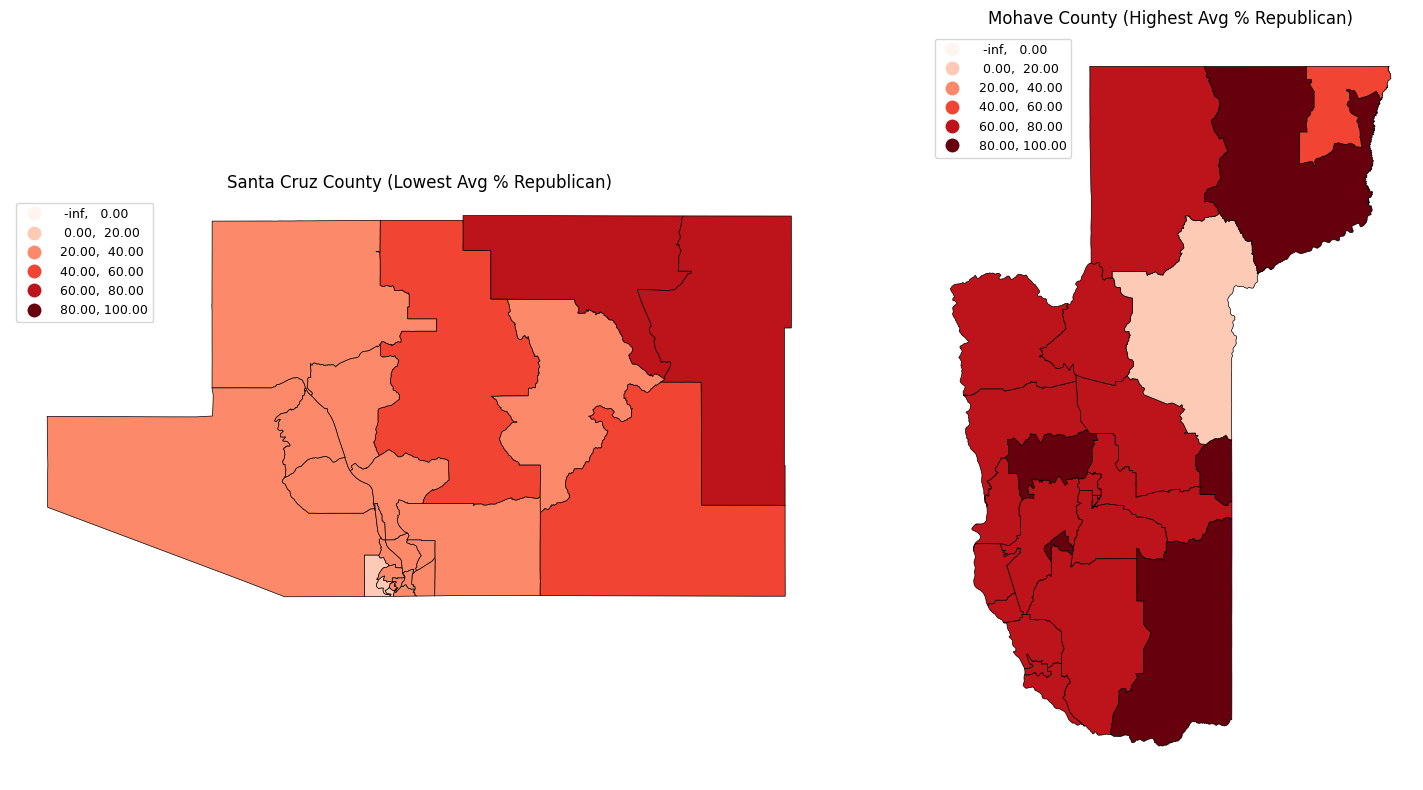

In [15]:
# Choropleth maps with User Defined Classification
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Lowest county
gdf_low.plot(
    column="pct_rep",
    scheme="UserDefined",
    classification_kwds={"bins": [0, 20, 40, 60, 80, 100]},
    cmap="Reds",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    legend_kwds={"loc": "upper left", "fontsize": 9},
    ax=axes[0],
)
axes[0].set_title(f"{lowest_county} County (Lowest Avg % Republican)")
axes[0].set_axis_off()

# Highest county
gdf_high.plot(
    column="pct_rep",
    scheme="UserDefined",
    classification_kwds={"bins": [0, 20, 40, 60, 80, 100]},
    cmap="Reds",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    legend_kwds={"loc": "upper left", "fontsize": 9},
    ax=axes[1],
)
axes[1].set_title(f"{highest_county} County (Highest Avg % Republican)")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

17. Plot the same two counties as before, but this time use Fisher-Jenks with `k=5`. Map formatting should include:
    - 5 classes
    - Show the legend
    - Use red color pallet
    - Ensure precinct lines are visible, but not exaggerated
    - Remove the axis with the mapping coordinates
    - Legend values should display one decimal place (e.g., 24.7)
    - Adjust the legend location and font size to make the map look nice

    Discuss the ease of comparing two maps using a single user defined classification (i.e., in the previous question) versus comparing two maps using Fisher-Jenks (i.e., this question).

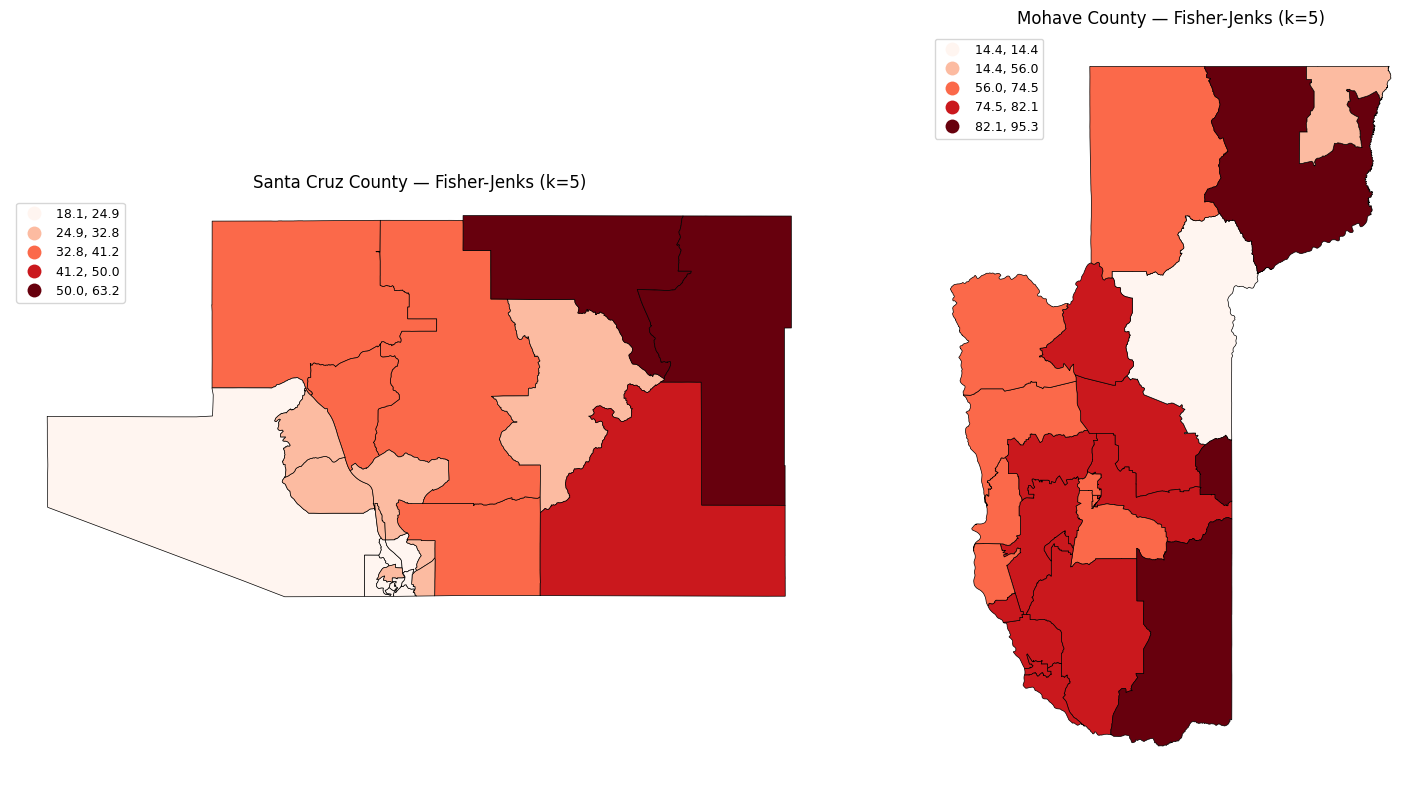

In [16]:
# Fisher-Jenks maps for both counties
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Lowest county
gdf_low.plot(
    column="pct_rep",
    scheme="FisherJenks",
    k=5,
    cmap="Reds",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    legend_kwds={"loc": "upper left", "fontsize": 9, "fmt": "{:.1f}"},
    ax=axes[0],
)
axes[0].set_title(f"{lowest_county} County — Fisher-Jenks (k=5)")
axes[0].set_axis_off()

# Highest county
gdf_high.plot(
    column="pct_rep",
    scheme="FisherJenks",
    k=5,
    cmap="Reds",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    legend_kwds={"loc": "upper left", "fontsize": 9, "fmt": "{:.1f}"},
    ax=axes[1],
)
axes[1].set_title(f"{highest_county} County — Fisher-Jenks (k=5)")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

**User-Defined Classification (Q16) vs Fisher-Jenks (Q17):**

With the user-defined 20% interval classification, both maps use identical class boundaries. This makes direct comparison straightforward: a given shade of red means exactly the same percentage range on both maps. You can immediately see that the lowest-average county is dominated by lighter colors (lower Republican percentages) and the highest-average county by darker colors (higher percentages). The shared legend makes the comparison intuitive.

With Fisher-Jenks, each county gets its own optimized class boundaries based on natural breaks in that county's data. While each individual map maximizes its internal visual contrast and reveals local variation effectively, the two maps are no longer comparable — the same shade of red represents entirely different percentage ranges on each map. A precinct colored in the darkest red in the lowest county might have a much lower Republican percentage than a precinct in the lightest red of the highest county.

This highlights the trade-off: user-defined classification sacrifices local detail for cross-map comparability, while Fisher-Jenks sacrifices comparability for local detail.